**GLOBAL SETUP**

In [20]:
import os
import random
import numpy as np
import cv2
from PIL import Image
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import kagglehub
import albumentations as A
import matplotlib.pyplot as plt
import seaborn as sns

IMG_SIZE = (256,256)
BATCH_SIZE = 16
EPOCHS = 40
PATIENCE = 7
DROPOUT_VAL = 0.2

# -----------------------------
# Download Dataset
# -----------------------------

path = kagglehub.dataset_download("briscdataset/brisc2025")
print("Dataset:", path)

base_seg_dir = os.path.join(path,"brisc2025","segmentation_task")

if not os.path.exists(base_seg_dir):
    base_seg_dir = os.path.join(path,"segmentation_task")

# -----------------------------
# Data pairing
# -----------------------------

def get_pairs(split):

    img_dir = os.path.join(base_seg_dir,split,"images")
    mask_dir = os.path.join(base_seg_dir,split,"masks")

    imgs = sorted([os.path.join(img_dir,f) for f in os.listdir(img_dir) if f.endswith(".jpg")])
    msks = sorted([os.path.join(mask_dir,f) for f in os.listdir(mask_dir) if f.endswith(".png")])

    return list(zip(imgs,msks))


all_train_pairs = get_pairs("train")
test_pairs = get_pairs("test")

random.shuffle(all_train_pairs)

split = int(0.8*len(all_train_pairs))

train_pairs = all_train_pairs[:split]
val_pairs = all_train_pairs[split:]

print("Train:",len(train_pairs),"Val:",len(val_pairs),"Test:",len(test_pairs))

Using Colab cache for faster access to the 'brisc2025' dataset.
Dataset: /kaggle/input/brisc2025
Train: 3146 Val: 787 Test: 860


**AUGMENTATION AND DATASET**

In [21]:
# -----------------------------
# Augmentation
# -----------------------------

aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(0.05,0.05,15,p=0.3),
])


# -----------------------------
# Dataset Loader
# -----------------------------

class BRISCDataset(tf.keras.utils.Sequence):

    def __init__(self,pairs,batch_size=BATCH_SIZE,augment=False):

        self.pairs = pairs
        self.batch_size = batch_size
        self.augment = augment
        self.indexes = np.arange(len(pairs))

    def __len__(self):

        return int(np.ceil(len(self.pairs)/self.batch_size))

    def on_epoch_end(self):

        np.random.shuffle(self.indexes)

    def __getitem__(self,idx):

        indices = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]

        imgs=[]
        msks=[]

        for i in indices:

            img = np.array(Image.open(self.pairs[i][0]).convert("L").resize(IMG_SIZE))
            msk = np.array(Image.open(self.pairs[i][1]).convert("L").resize(IMG_SIZE))

            if self.augment:

                aug = aug_pipeline(image=img,mask=msk)
                img = aug["image"]
                msk = aug["mask"]

            img = img.astype("float32")/255.0
            msk = (msk>0).astype("float32")

            imgs.append(np.expand_dims(img,-1))
            msks.append(np.expand_dims(msk,-1))

        return np.array(imgs),np.array(msks)


train_loader = BRISCDataset(train_pairs,augment=True)
val_loader = BRISCDataset(val_pairs)
test_loader = BRISCDataset(test_pairs)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


**METRICS AND LOSS**

In [22]:
# -----------------------------
# Metrics
# -----------------------------

def dice_coef(y_true,y_pred):

    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true*y_pred)

    return (2*intersection+1e-7)/(K.sum(y_true)+K.sum(y_pred)+1e-7)


def iou_coef(y_true,y_pred):

    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    inter = K.sum(y_true*y_pred)

    return (inter+1e-7)/(K.sum(y_true)+K.sum(y_pred)-inter+1e-7)


# -----------------------------
# Loss
# -----------------------------

def focal_tversky_loss(y_true,y_pred,alpha=0.7,beta=0.3,gamma=0.75):

    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    tp = K.sum(y_true*y_pred)
    fn = K.sum(y_true*(1-y_pred))
    fp = K.sum((1-y_true)*y_pred)

    tversky = (tp+1e-7)/(tp+alpha*fn+beta*fp+1e-7)

    return K.pow((1-tversky),gamma)

**DEEPLABV3 ARCHI (pre-trained)**

In [23]:
# -----------------------------
# Model
# -----------------------------

def conv_block(x,filters):

    x = layers.Conv2D(filters,3,padding="same",activation="relu")(x)
    x = layers.BatchNormalization()(x)

    return x


def build_deeplab():

    inputs = layers.Input((*IMG_SIZE,1))

    x = conv_block(inputs,64)
    low = layers.MaxPooling2D(4)(x)

    x = layers.MaxPooling2D(4)(x)
    x = conv_block(x,128)

    a = layers.Conv2D(256,1,activation="relu",padding="same")(x)
    b = layers.Conv2D(256,3,dilation_rate=6,padding="same",activation="relu")(x)
    c = layers.Conv2D(256,3,dilation_rate=12,padding="same",activation="relu")(x)

    x = layers.Concatenate()([a,b,c])

    x = conv_block(x,256)

    x = layers.Concatenate()([x,low])

    x = conv_block(x,256)

    x = layers.UpSampling2D(4,interpolation="bilinear")(x)

    outputs = layers.Conv2D(1,1,activation="sigmoid")(x)

    return models.Model(inputs,outputs)

**OPTIMIZERS**

In [24]:
# -----------------------------
# Optimizers
# -----------------------------

optimizer_settings = {

    "Adam": lambda: tf.keras.optimizers.Adam(5e-5),
    "SGD": lambda: tf.keras.optimizers.SGD(1e-3,momentum=0.9)

}

all_histories = {}
final_results = []

**TRAINING AND MONITORING**

In [25]:
# -----------------------------
# Training Loop
# -----------------------------

for name,opt in optimizer_settings.items():

    print("\nTraining with",name)

    model = build_deeplab()

    model.compile(
        optimizer=opt(),
        loss=focal_tversky_loss,
        metrics=[dice_coef,iou_coef,"accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(

        train_loader,
        validation_data=val_loader,
        epochs=EPOCHS,
        callbacks=[early_stop]

    )

    res = model.evaluate(test_loader)

    final_results.append([name,res[0],res[1],res[2]])

    all_histories[name] = history


Training with Adam


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 160s 631ms/step - accuracy: 0.7185 - dice_coef: 0.1133 - iou_coef: 0.0606 - loss: 0.8684 - val_accuracy: 0.6470 - val_dice_coef: 0.0954 - val_iou_coef: 0.0502 - val_loss: 0.8862
Epoch 2/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 102s 518ms/step - accuracy: 0.9064 - dice_coef: 0.2120 - iou_coef: 0.1192 - loss: 0.7648 - val_accuracy: 0.5813 - val_dice_coef: 0.0807 - val_iou_coef: 0.0421 - val_loss: 0.9020
Epoch 3/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 103s 522ms/step - accuracy: 0.9312 - dice_coef: 0.2710 - iou_coef: 0.1575 - loss: 0.7059 - val_accuracy: 0.9287 - val_dice_coef: 0.2629 - val_iou_coef: 0.1526 - val_loss: 0.7251
Epoch 4/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 102s 518ms/step - accuracy: 0.9489 - dice_coef: 0.3306 - iou_coef: 0.1991 - loss: 0.6504 - val_accuracy: 0.9658 - val_dice_coef: 0.4255 - val_iou_coef: 0.2723 - val_loss: 0.5886
Epoch 5/40
197/197 ━━━━━━━━━━━━━━━━━━━━ 102s 517ms/step - accuracy: 0.9657 - dice_coef: 0.3966 - iou_coef: 0.2496 - loss: 0.5939

**SAVE THE MODEL**

In [26]:
# -----------------------------
# Save Trained Model
# -----------------------------

model.save("deeplabv3plus_final_model_hyp.h5")

print("Model saved as deeplabv3plus_final_model_hyp.h5")

Model saved as deeplabv3plus_final_model_hyp.h5


**VISUALIZATIONS**

DeepLabV3+ Model Summary:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 256, 256,  │        640 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 64, 64,    │     33,024 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 64, 64,    │    295,168 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 64, 64,    │    295,168 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 64, 64,    │          0 │ conv2d_26[0][0],  │
│ (Concatenate)       │ 768)              │            │ conv2d_27[0][0],  │
│                     │                   │            │ conv2d_28[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 64, 64,    │  1,769,728 │ concatenate_6[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Concatenate)       │ 320)              │            │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 64, 64,    │    737,536 │ concatenate_7[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,414,980 (24.47 MB)

 Trainable params: 3,206,785 (12.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

 Optimizer params: 3,206,787 (12.23 MB)

Adam            | 0.7837      | 0.6465
SGD             | 0.6917      | 0.5332
--------------------------------------------------
CONCLUSION: Adam OPTIMIZER IS MATHEMATICALLY SUPERIOR.


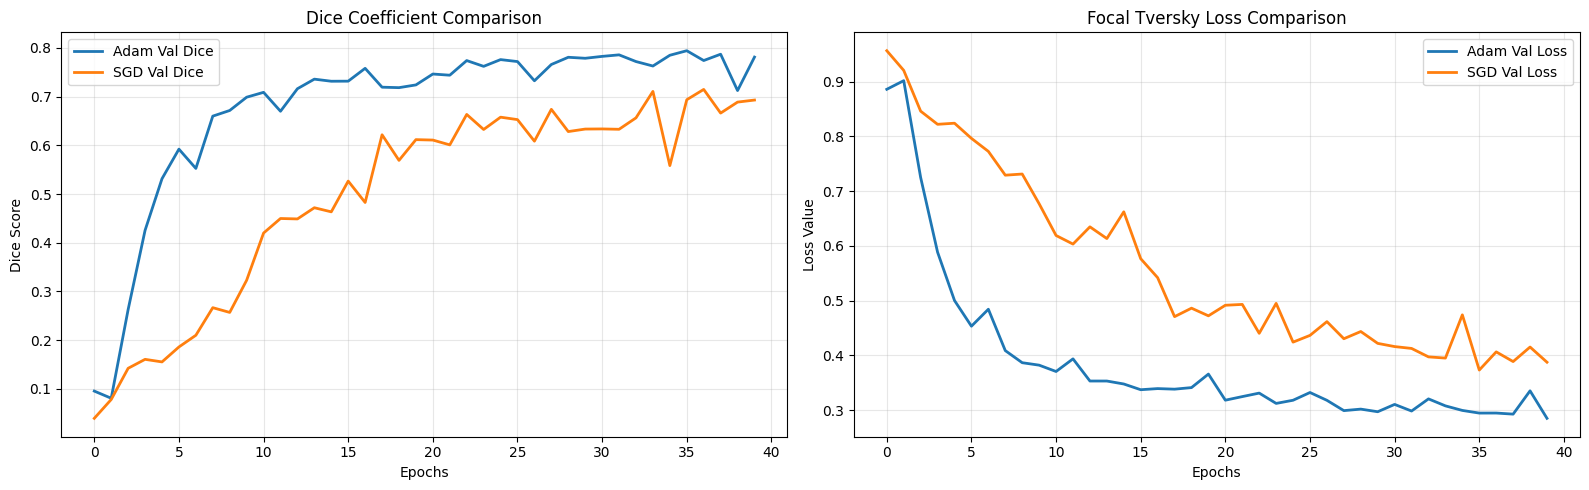

Test Loss: 0.3701, Dice: 0.6883, IoU: 0.5298, Accuracy: 0.9840


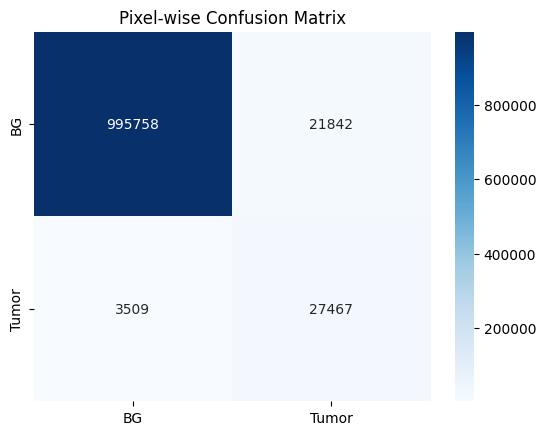

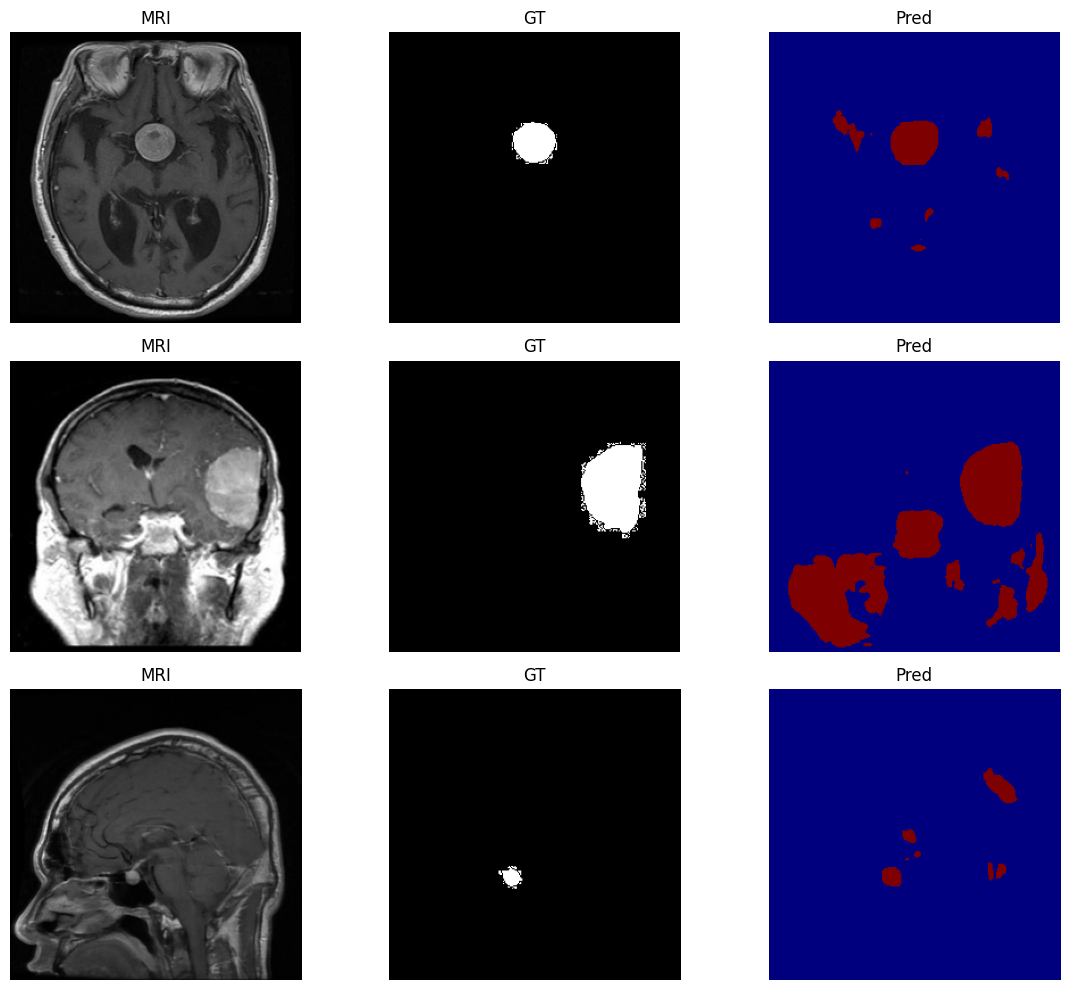

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import confusion_matrix

#Model Summary
print("DeepLabV3+ Model Summary:")
model.summary()


#Optimizer Comparison Graph
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

for name, h in all_histories.items():
    ax[0].plot(h.history["val_dice_coef"], label=f"{name} Val Dice", lw=2)
    ax[0].set_title("Dice Coefficient Comparison"); ax[0].set_ylabel("Dice Score")

    ax[1].plot(h.history["val_loss"], label=f"{name} Val Loss", lw=2)
    ax[1].set_title("Focal Tversky Loss Comparison"); ax[1].set_ylabel("Loss Value")

for a in ax: a.legend(); a.set_xlabel("Epochs"); a.grid(alpha=0.3)

# final_results contains: [name, test_loss, dice_coef, iou_coef]
for r in final_results:
    print(f"{r[0]:<15} | {r[2]:.4f}      | {r[3]:.4f}")

# Extract the optimal performer
best_idx = np.argmax([r[2] for r in final_results])
target_opt = final_results[best_idx][0]

print("-" * 50)
print(f"CONCLUSION: {target_opt} OPTIMIZER IS MATHEMATICALLY SUPERIOR.")
print("="*50)
plt.tight_layout(); plt.show()
#Final Metrics
results = model.evaluate(test_loader, verbose=0)
print(f"Test Loss: {results[0]:.4f}, Dice: {results[1]:.4f}, IoU: {results[2]:.4f}, Accuracy: {results[3]:.4f}")

#Confusion Matrix
batch_idx = random.randint(0, len(test_loader)-1)
imgs, msks = test_loader[batch_idx]
preds = model.predict(imgs, verbose=0)
cm = confusion_matrix(msks.flatten()>0.5, preds.flatten()>0.5)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['BG','Tumor'], yticklabels=['BG','Tumor'])
plt.title("Pixel-wise Confusion Matrix"); plt.show()

#Sample Predictions
indices = random.sample(range(len(imgs)), min(3, len(imgs)))
plt.figure(figsize=(12,10))
for i, idx in enumerate(indices):
    plt.subplot(3,3,i*3+1); plt.imshow(imgs[idx].reshape(IMG_SIZE), cmap='gray'); plt.title("MRI"); plt.axis('off')
    plt.subplot(3,3,i*3+2); plt.imshow(msks[idx].reshape(IMG_SIZE), cmap='gray'); plt.title("GT"); plt.axis('off')
    plt.subplot(3,3,i*3+3); plt.imshow(preds[idx].reshape(IMG_SIZE)>0.5, cmap='jet'); plt.title("Pred"); plt.axis('off')
plt.tight_layout(); plt.show()